# Tutorial 6 — From the structured-jet chain to detection forecasts

This notebook loads the converged **Tutorial 2** chain, generates a full catalogue,
applies the prompt sensitivities, adds the BNS parameters, runs GWFish, and computes
the X-ray afterglows. Set the chain path and simulation duration below, then **Run All**.
The jet fraction comes directly from the selected chain sample.

The default merger-rate file and jet structure match Tutorial 2. For a Tutorial 2.1
chain, point `CHAIN_PATH` to that run and set `STRUCTURE_CSV` to its structure file.
Keep `forecast_pipeline.py` beside the notebook in `Tutorials/`.

In your MAGGPY environment, install the additional tools if needed:

```bash
python -m pip install VegasAfterglow==2.0.4 joblib PyYAML lalsuite matplotlib ipykernel
python -m pip install "GWFish @ git+https://github.com/janosch314/GWFish.git"
```

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from dataclasses import asdict
import sys

import emcee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from maggpy.structured_jet.init import initialize_simulation, load_custom_structure_constants

ROOT = Path.cwd().resolve()
if ROOT.name == 'Tutorials': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'Tutorials'))
import forecast_pipeline as fp

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.2})

## 1. Settings

`CHAIN_PATH` points to the `emcee.h5` saved by Tutorial 2. `BURN_IN` is the number
of steps to discard. Keep `MRD_PATH` and `STRUCTURE_CSV` consistent with the fitted run.
`N_YEARS` is the physical duration of the generated catalogue.

In [38]:
CHAIN_PATH      = ROOT / 'Tutorials' / 'Output_files' / 'tutorial2_structured' / 'emcee.h5'
BURN_IN         = 300
N_YEARS         = 0.5 # for testing
DATA_DIR        = ROOT / 'datafiles'
MRD_PATH        = DATA_DIR / 'MRD_outputs' / 'fiducial_A1_0_BNS.csv'
STRUCTURE_CSV   = None      # Tutorial 2; for 2.1 use DATA_DIR / 'structure_constants/struct_results_100.csv'
THETA_V_MAX_DEG = 30.
SEED            = 42
N_JOBS          = 4               # Set to 1 for a serial run.
OUTPUT_DIR = ROOT / 'Output_files' / 'tutorial6_forecasts'

# FOV of 8 str out of 4 * pi
FOV_8sr_fraction = 8. / (4 * np.pi)

PROMPT = (
    fp.PromptInstrument('GRINTA_TED', (50., 300.), 1., 0.32 * 3/5, 'ph', 0.5*FOV_8sr_fraction), #5sigma it's already so high but we'll keep this number 
    fp.PromptInstrument('Crystal_Eye', (50., 300.), 2, 0.180, 'ph', 0.3), #3sigma
    fp.PromptInstrument('THESEUS_XGIS', (30., 150.), 1., 3e-8, 'erg', 0.16 * 0.65, 15., 0.9), #3sigma
)
MAX_T90_S = None          # Set to 2.0 if you want T90 < 2 s; otherwise apply flux cuts only.

NETWORKS = {
    'Asharp'        : ['LLO_sharp', 'LHO_sharp', 'LIO_sharp'],
    'ET_2L'         : ['ETS_15', 'ETN_15'],
    'ET_triangle'   : ['ET'],
}
WAVEFORM = 'IMRPhenomD_NRTidalv2'    # Or 'TaylorF2'.
GW_SNR_THRESHOLD = 8.
LOCALIZATION_CUTS_DEG2 = (1., 10., 100., 1000.)

AFTERGLOW_IMAGERS = fp.DEFAULT_AFTERGLOW
RESPONSE_DELAYS_S = (0., 100., 300., 3600.)
GW_FOLLOWUP_AREA90_MAX_DEG2 = 100.
AFTERGLOW_THETA_CORE_DEG = 5.

## 2. Load the chain and initialize the fitted population

As in Tutorial 2.1, use the retained sample with the highest log probability.
All seven parameters, including $f_j$, come from that sample.

In [39]:
backend = emcee.backends.HDFBackend(str(CHAIN_PATH), read_only=True)
chain = backend.get_chain(discard=BURN_IN, flat=True)
log_probability = backend.get_log_prob(discard=BURN_IN, flat=True)
theta = chain[np.argmax(log_probability)]
#take median not max
theta = np.median(chain, axis=0)
parameter_names = ['k', 'L_L0', 'L_mu_E', 'sigma_E', 'L_mu_tau', 'sigma_tau', 'f_j']
fitted_parameters = pd.Series(theta, index=parameter_names, name='fitted value')
display(fitted_parameters.to_frame())

simulation, interps, _ = initialize_simulation(
    DATA_DIR, MRD_PATH, params={'theta_v_max': THETA_V_MAX_DEG}, size_test=10_000)
if STRUCTURE_CSV is not None:
    simulation = load_custom_structure_constants(simulation, STRUCTURE_CSV)
simulation.rng = np.random.default_rng(SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fitted_parameters.to_csv(OUTPUT_DIR / 'fitted_parameters.csv')

,fitted value
k,3.687700
L_L0,-0.827366
L_mu_E,3.467122
sigma_E,0.379286
L_mu_tau,-0.610128
sigma_tau,0.727274
f_j,0.679574


## 3. Generate the full catalogue and observables

Sample all jet sources over `N_YEARS` within the chosen viewing-angle range,
using the fitted population and MAGGPY's spectral and temporal model. The catalogue
includes redshift, viewing angle, peak energy, flux, fluence, duration and intrinsic
isotropic energy. Generation runs in small batches to limit memory use.

Instrument coverage is applied in the next step, so every annual rate is simply
the selected number of events divided by `N_YEARS`.

In [40]:
catalogue = fp.make_full_catalogue(theta, simulation, interps, years=N_YEARS)
catalogue.to_csv(OUTPUT_DIR / 'full_catalogue.csv', index=False)
display(catalogue.head())

Generating 16,321 sources for 0.5 years; f_j = 0.68


,event_id,z,theta_v_rad,theta_v_deg,Ep_keV,Ep_onaxis_rest_keV,peak_ph_50_300,peak64_ph_50_300,fluence_50_300_erg_cm2,t_peak_s,T90_s,E_iso_onaxis_erg,E_iso_structure_erg,alpha_e,alpha_n
0,0,1.124356,0.434032,24.868226,2.039988,1298.043705,8.567988e-11,6.834459e-11,2.941273e-18,0.082771,5.271082,1.075213e+51,4.790093e+45,0.337633,0.544475
1,1,2.562967,0.162582,9.315289,39.132678,2796.287618,2.004735e-06,1.886448e-06,1.655151e-13,0.353183,2.328601,1.386744e+51,1.490503e+48,0.473694,0.745796
2,2,1.117739,0.346673,19.862926,8.250355,2106.215632,1.036854e-09,1.012304e-09,2.885249e-16,0.819527,25.176804,1.439692e+51,3.707913e+46,0.374339,0.587855
3,3,1.659677,0.435151,24.932300,7.387519,5999.230512,3.164159e-11,2.909293e-11,3.001271e-18,0.227898,14.513087,7.629355e+50,3.190863e+45,0.337163,0.543920
4,4,1.629406,0.452713,25.938535,5.327802,6147.907474,-2.705755e-13,-2.442358e-13,-4.774123e-20,0.404837,404.837319,1.162140e+51,-1.158036e+44,0.329784,0.535199


## 4. Prompt detections

Compare the maximum window-averaged flux with each threshold: TED uses 1 s in
50–300 keV, Crystal Eye 2 s in 50–300 keV, and XGIS 1 s in 30–150 keV.
GRINTA uses GBM-like coverage (0.6); Crystal Eye uses half that value.
XGIS uses an imaging sky fraction of 0.16 and an editable duty assumption of 0.65.
Its flux is integrated as energy flux; the other two use photon flux.

,name,band_keV,window_s,flux_limit,flux_unit,observing_efficiency,position_arcmin,position_fraction
0,GRINTA_TED,"(50.0, 300.0)",1.0,1.920000e-01,ph,0.31831,NaN,NaN
1,Crystal_Eye,"(50.0, 300.0)",2.0,1.800000e-01,ph,0.30000,NaN,NaN
2,THESEUS_XGIS,"(30.0, 150.0)",1.0,3.000000e-08,erg,0.10400,15.0,0.9


/mnt/c/Users/Ludovico/Desktop/CodeCleanup/MAGGPY/Tutorials/forecast_pipeline.py:95: RuntimeWarning: invalid value encountered in log
  return np.exp(np.interp(np.log(ep), self.log_ep, self.tables[(tuple(band), unit)]))
/mnt/c/Users/Ludovico/Desktop/CodeCleanup/MAGGPY/Tutorials/forecast_pipeline.py:95: RuntimeWarning: invalid value encountered in log
  return np.exp(np.interp(np.log(ep), self.log_ep, self.tables[(tuple(band), unit)]))
/mnt/c/Users/Ludovico/Desktop/CodeCleanup/MAGGPY/Tutorials/forecast_pipeline.py:95: RuntimeWarning: invalid value encountered in log
  return np.exp(np.interp(np.log(ep), self.log_ep, self.tables[(tuple(band), unit)]))


,instrument,band_keV,window_s,flux_limit,flux_unit,observing_efficiency,flux_qualified_count,count,rate_per_yr,median_z,median_viewing_angle_deg
0,GRINTA_TED,50-300,1.0,1.920000e-01,ph,0.31831,110,36,72.0,1.151921,2.429376
1,Crystal_Eye,50-300,2.0,1.800000e-01,ph,0.30000,76,19,38.0,0.935462,2.295866
2,THESEUS_XGIS,30-150,1.0,3.000000e-08,erg,0.10400,79,7,14.0,1.307639,4.061384


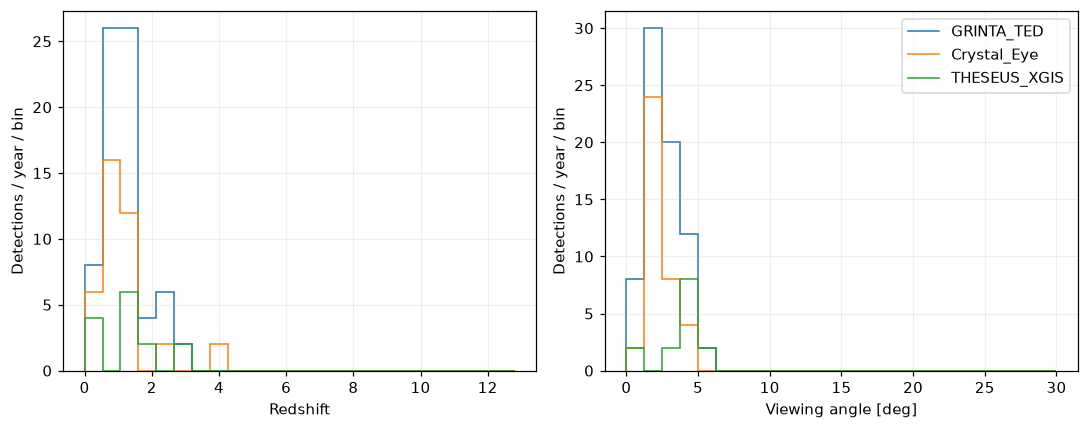

In [41]:
display(pd.DataFrame([asdict(instrument) for instrument in PROMPT]))
events = fp.select_prompt(catalogue, instruments=PROMPT, seed=SEED, max_t90_s=MAX_T90_S)
prompt_table = fp.prompt_summary(events, N_YEARS, instruments=PROMPT)
display(prompt_table)
prompt_table.to_csv(OUTPUT_DIR / 'prompt_rates.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bins = {'z': np.linspace(0, events.z.max(), 25),
        'theta_v_deg': np.linspace(0, THETA_V_MAX_DEG, 25)}
for instrument in PROMPT:
    selected = events[f'prompt_{instrument.name}']
    for ax, column in zip(axes, ('z', 'theta_v_deg')):
        counts, edges = np.histogram(events.loc[selected, column], bins=bins[column])
        ax.stairs(counts / N_YEARS, edges, label=instrument.name)
axes[0].set(xlabel='Redshift', ylabel='Detections / year / bin')
axes[1].set(xlabel='Viewing angle [deg]', ylabel='Detections / year / bin')
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'prompt_distributions.pdf')
plt.show()

## 5. Joint GW detections and localizations

Use the catalogue's redshift and viewing angle for each BNS. Add the tutorial mass
distribution ($1.33\pm0.09\,M_\odot$), sky position, polarization and coalescence time.
GWFish computes the SNRs and 90% Fisher sky areas. The comparison assumes all GW
detectors are operational. Sources without prompt triggers are retained for the
GW-triggered afterglow analysis.

The joint table reports annual rates and GW localization counts below each area cut.
XGIS imaging benchmarks are ≤7 arcmin for 50% and ≤15 arcmin for 90% of triggered
sGRBs; these are mission requirements rather than fitted per-event positions.

GWFish: 16,321 sources, 6 detectors
  Asharp: 99 GW detections


  0%|          | 0/256 [00:00<?, ?it/s]

  ET_2L: 7,823 GW detections


100%|██████████| 256/256 [00:23<00:00, 11.11it/s]


  ET_triangle: 4,696 GW detections


100%|██████████| 256/256 [00:18<00:00, 13.64it/s]


,instrument,network,count,rate_per_yr,median_z,z_90th_percentile,median_viewing_angle_deg,joint_without_valid_localization,median_area90_deg2,localized_le_1_deg2_count,localized_le_1_deg2_per_yr,localized_le_10_deg2_count,localized_le_10_deg2_per_yr,localized_le_100_deg2_count,localized_le_100_deg2_per_yr,localized_le_1000_deg2_count,localized_le_1000_deg2_per_yr,em_position_arcmin_benchmark,em_position_fraction_requirement
0,GRINTA_TED,Asharp,3,6.0,0.282303,0.367330,4.822515,0,78.833765,0,0.0,0,0.0,2,4.0,3,6.0,NaN,NaN
1,Crystal_Eye,Asharp,2,4.0,0.432036,0.476338,3.549171,0,477.576717,0,0.0,0,0.0,0,0.0,2,4.0,NaN,NaN
2,THESEUS_XGIS,Asharp,1,2.0,0.282303,0.282303,4.849487,0,78.833765,0,0.0,0,0.0,1,2.0,1,2.0,15.0,0.9
3,GRINTA_TED,ET_2L,26,52.0,0.913397,1.382928,2.429376,0,962.191662,0,0.0,0,0.0,2,4.0,13,26.0,NaN,NaN
4,Crystal_Eye,ET_2L,15,30.0,0.904950,1.381518,2.310352,0,1013.221928,0,0.0,0,0.0,3,6.0,7,14.0,NaN,NaN
5,THESEUS_XGIS,ET_2L,4,8.0,0.865649,1.315834,4.711343,0,833.410876,0,0.0,0,0.0,0,0.0,2,4.0,15.0,0.9
6,GRINTA_TED,ET_triangle,25,50.0,0.904950,1.397985,2.362155,0,18532.745789,0,0.0,0,0.0,1,2.0,5,10.0,NaN,NaN
7,Crystal_Eye,ET_triangle,14,28.0,0.869278,1.384615,2.027065,0,7751.410220,0,0.0,0,0.0,2,4.0,3,6.0,NaN,NaN
8,THESEUS_XGIS,ET_triangle,4,8.0,0.865649,1.315834,4.711343,0,577642.700639,0,0.0,0,0.0,0,0.0,2,4.0,15.0,0.9


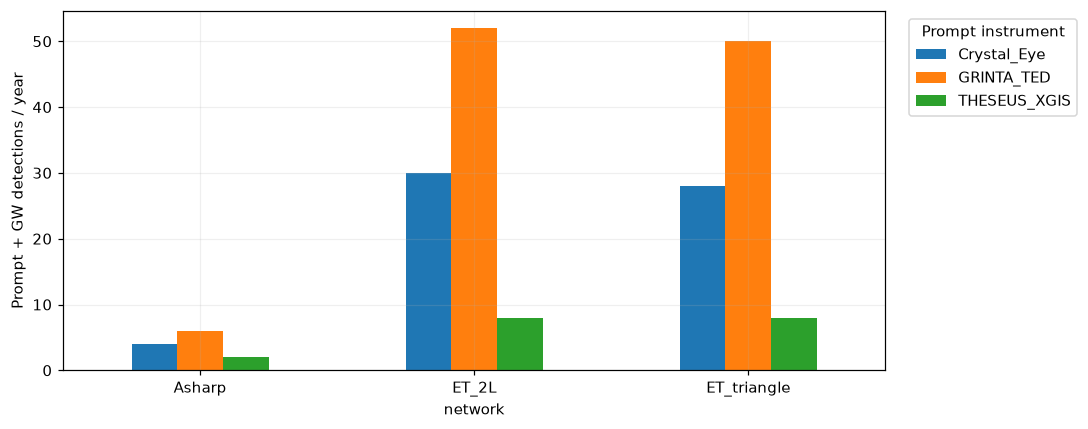

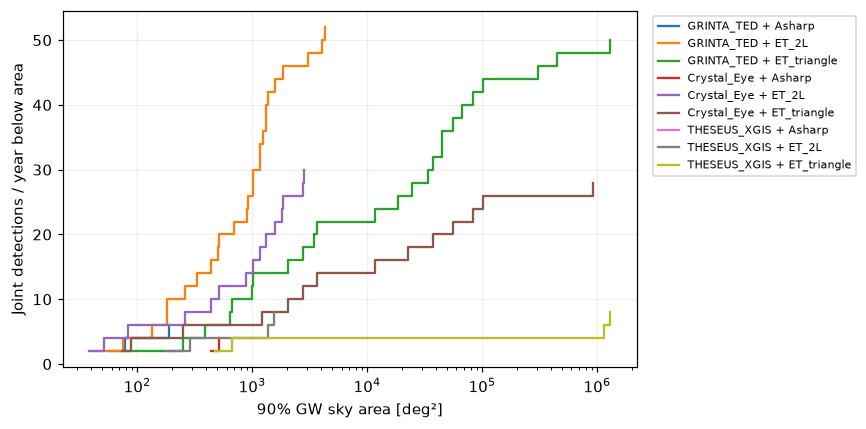

In [6]:
binaries        = fp.binary_parameters(events, seed=SEED)
detector_names  = sorted({detector for network in NETWORKS.values() for detector in network})
gw_config       = fp.resolve_gw_config(
    ROOT / 'Tutorials' / 'configs' / 'coba.yaml', ROOT / 'Tutorials' / 'psds',
    OUTPUT_DIR / 'detectors.yaml', detector_names)
gw_results = fp.run_gw(binaries, NETWORKS, gw_config, waveform=WAVEFORM,
                       threshold=GW_SNR_THRESHOLD, n_jobs=N_JOBS)
joint_table = fp.joint_summary(events, gw_results, N_YEARS, instruments=PROMPT,
                                localization_cuts=LOCALIZATION_CUTS_DEG2)
display(joint_table)
joint_table.to_csv(OUTPUT_DIR / 'joint_prompt_rates.csv', index=False)
pd.concat([events, binaries.add_prefix('bns_'), gw_results], axis=1).to_csv(
    OUTPUT_DIR / 'events_prompt_gw.csv', index=False)

ax = joint_table.pivot(index='network', columns='instrument', values='rate_per_yr').plot.bar(
    figsize=(10, 4), rot=0, ylabel='Prompt + GW detections / year')
ax.legend(title='Prompt instrument', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'joint_prompt_rates.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
for instrument in PROMPT:
    for network in NETWORKS:
        joint = events[f'prompt_{instrument.name}'] & gw_results[f'gw_{network}']
        area = gw_results.loc[joint, f'area90_{network}_deg2'].dropna().sort_values()
        if len(area):
            ax.step(area, np.arange(1, len(area) + 1) / N_YEARS, where='post',
                    label=f'{instrument.name} + {network}')
ax.set(xscale='log', xlabel='90% GW sky area [deg²]', ylabel='Joint detections / year below area')
if ax.get_legend_handles_labels()[0]:
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'joint_localization_cumulative.pdf')
plt.show()

## 6. Afterglows and additional counterparts

VegasAfterglow uses the same source's $E_{\rm iso}$, redshift and viewing angle,
with the supplied 5° top-hat afterglow setup. The density, $\epsilon_B$ and Lorentz
factor are drawn once per source and reused across the comparisons.

HXI uses 5–30 keV and $1.2\times10^{-3}\sqrt{10^4/\Delta t}$ ph cm$^{-2}$ s$^{-1}$.
SXI uses the [Yellow Book](https://sci.esa.int/documents/34375/36249/Theseus_YB_final.pdf)
sensitivities: $10^{-10}$ erg cm$^{-2}$ s$^{-1}$ at 100 s and
$1.8\times10^{-11}$ at 1,500 s, in 0.3–5 keV. Each exposure starts after its
alert and response delay. The calculation finds the best exposure during the light curve.

`followup_fraction=1` assumes that follow-up is arranged; edit the imager values
to include availability. GW follow-up requires the selected localization cut.
The rate table reports prompt + GW events with afterglows, GW-triggered afterglows,
and the **additional events without a prompt detection** in that instrument.

,name,band_keV,flux_unit,exposures_s,limits,followup_fraction,position_arcmin
0,GRINTA_HXI,"(5.0, 30.0)",ph,"(10.0, 100.0, 1000.0, 10000.0, 100000.0)","(0.03794733192202055, 0.011999999999999999, 0....",1.0,NaN
1,THESEUS_SXI,"(0.3, 5.0)",erg,"(100.0, 1500.0)","(1e-10, 1.8e-11)",1.0,2.0


VegasAfterglow: 112 sources


,prompt_instrument,imager,network,delay_s,gw_localization_cut_deg2,followup_fraction,afterglow_position_arcmin,prompt_joint_count,prompt_afterglow_joint_count,prompt_afterglow_joint_per_yr,gw_triggered_afterglow_count,gw_triggered_afterglow_per_yr,extra_without_prompt_count,extra_without_prompt_per_yr,unique_prompt_or_added_afterglow_count,unique_prompt_or_added_afterglow_per_yr
0,GRINTA_TED,GRINTA_HXI,Asharp,0.0,100.0,1.0,NaN,3,0,0.0,0,0.0,0,0.0,3,6.0
1,GRINTA_TED,GRINTA_HXI,ET_2L,0.0,100.0,1.0,NaN,26,0,0.0,1,2.0,1,2.0,27,54.0
2,GRINTA_TED,GRINTA_HXI,ET_triangle,0.0,100.0,1.0,NaN,25,0,0.0,1,2.0,1,2.0,26,52.0
3,Crystal_Eye,GRINTA_HXI,Asharp,0.0,100.0,1.0,NaN,2,0,0.0,0,0.0,0,0.0,2,4.0
4,Crystal_Eye,GRINTA_HXI,ET_2L,0.0,100.0,1.0,NaN,15,0,0.0,1,2.0,1,2.0,16,32.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Crystal_Eye,THESEUS_SXI,ET_2L,3600.0,100.0,1.0,2.0,15,0,0.0,0,0.0,0,0.0,15,30.0
68,Crystal_Eye,THESEUS_SXI,ET_triangle,3600.0,100.0,1.0,2.0,14,0,0.0,0,0.0,0,0.0,14,28.0
69,THESEUS_XGIS,THESEUS_SXI,Asharp,3600.0,100.0,1.0,2.0,1,0,0.0,0,0.0,0,0.0,1,2.0
70,THESEUS_XGIS,THESEUS_SXI,ET_2L,3600.0,100.0,1.0,2.0,4,0,0.0,0,0.0,0,0.0,4,8.0


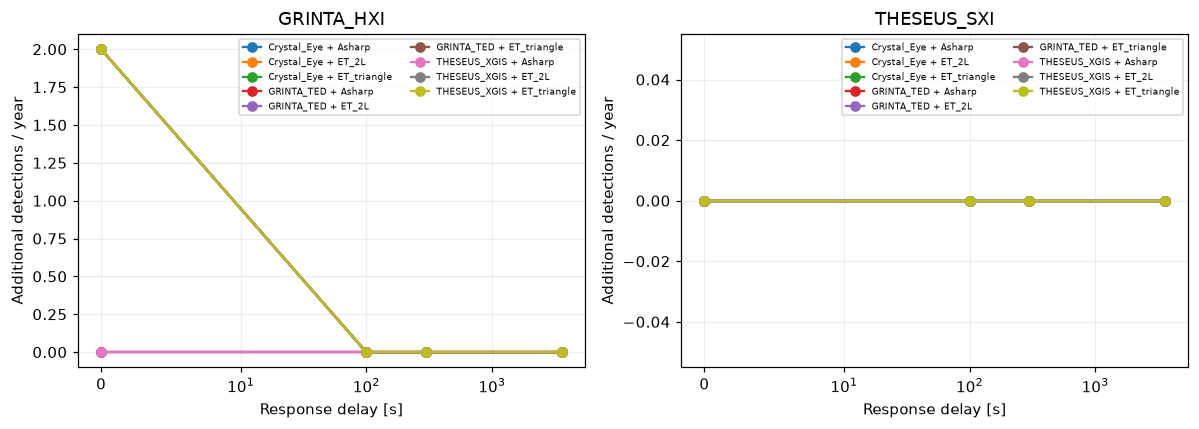

In [9]:
display(pd.DataFrame([asdict(imager) for imager in AFTERGLOW_IMAGERS]))
microphysics = fp.afterglow_parameters(events, seed=SEED)
afterglow_events = fp.run_afterglow(
    events, gw_results, microphysics, instruments=AFTERGLOW_IMAGERS,
    prompt_instruments=PROMPT, delays=RESPONSE_DELAYS_S,
    localization_cut=GW_FOLLOWUP_AREA90_MAX_DEG2,
    theta_core_deg=AFTERGLOW_THETA_CORE_DEG, n_jobs=N_JOBS)
afterglow_table = fp.afterglow_summary(
    events, gw_results, afterglow_events, N_YEARS,
    instruments=AFTERGLOW_IMAGERS, prompt_instruments=PROMPT,
    delays=RESPONSE_DELAYS_S, localization_cut=GW_FOLLOWUP_AREA90_MAX_DEG2, seed=SEED)
display(afterglow_table)
afterglow_table.to_csv(OUTPUT_DIR / 'afterglow_rates.csv', index=False)
afterglow_events.to_csv(OUTPUT_DIR / 'afterglow_events.csv', index=False)
microphysics.to_csv(OUTPUT_DIR / 'afterglow_parameters.csv', index=False)

fig, axes = plt.subplots(1, len(AFTERGLOW_IMAGERS), figsize=(11, 4), squeeze=False)
for ax, imager in zip(axes[0], AFTERGLOW_IMAGERS):
    rows = afterglow_table[afterglow_table.imager == imager.name]
    for (instrument, network), group in rows.groupby(['prompt_instrument', 'network']):
        group = group.sort_values('delay_s')
        ax.plot(group.delay_s, group.extra_without_prompt_per_yr, 'o-', label=f'{instrument} + {network}')
    ax.set(xlabel='Response delay [s]', ylabel='Additional detections / year', title=imager.name)
    ax.set_xscale('symlog', linthresh=10)
    ax.legend(fontsize=6, ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'extra_afterglow_rates.pdf')
plt.show()

## 7. Numbers for the chapter

Combine the joint rates, GW localizations and afterglow scenarios in one table.
`unique_prompt_or_added_afterglow` counts each counterpart once: prompt + GW
events plus the exclusive additions from GW-triggered afterglows.

In [10]:
chapter_numbers = joint_table.rename(columns={
    'instrument': 'prompt_instrument', 'count': 'prompt_joint_count',
    'rate_per_yr': 'prompt_joint_per_yr'})
chapter_numbers = chapter_numbers.merge(afterglow_table.drop(columns='prompt_joint_count'),
                                         on=['prompt_instrument', 'network'])
chapter_numbers.to_csv(OUTPUT_DIR / 'chapter_numbers.csv', index=False)
display(chapter_numbers)
print(f'Saved catalogues, rate tables and figures in {OUTPUT_DIR}')

,prompt_instrument,network,prompt_joint_count,prompt_joint_per_yr,median_z,z_90th_percentile,median_viewing_angle_deg,joint_without_valid_localization,median_area90_deg2,localized_le_1_deg2_count,...,followup_fraction,afterglow_position_arcmin,prompt_afterglow_joint_count,prompt_afterglow_joint_per_yr,gw_triggered_afterglow_count,gw_triggered_afterglow_per_yr,extra_without_prompt_count,extra_without_prompt_per_yr,unique_prompt_or_added_afterglow_count,unique_prompt_or_added_afterglow_per_yr
0,GRINTA_TED,Asharp,3,6.0,0.282303,0.367330,4.822515,0,78.833765,0,...,1.0,NaN,0,0.0,0,0.0,0,0.0,3,6.0
1,GRINTA_TED,Asharp,3,6.0,0.282303,0.367330,4.822515,0,78.833765,0,...,1.0,NaN,0,0.0,0,0.0,0,0.0,3,6.0
2,GRINTA_TED,Asharp,3,6.0,0.282303,0.367330,4.822515,0,78.833765,0,...,1.0,NaN,0,0.0,0,0.0,0,0.0,3,6.0
3,GRINTA_TED,Asharp,3,6.0,0.282303,0.367330,4.822515,0,78.833765,0,...,1.0,NaN,0,0.0,0,0.0,0,0.0,3,6.0
4,GRINTA_TED,Asharp,3,6.0,0.282303,0.367330,4.822515,0,78.833765,0,...,1.0,2.0,0,0.0,0,0.0,0,0.0,3,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,THESEUS_XGIS,ET_triangle,4,8.0,0.865649,1.315834,4.711343,0,577642.700639,0,...,1.0,NaN,0,0.0,0,0.0,0,0.0,4,8.0
68,THESEUS_XGIS,ET_triangle,4,8.0,0.865649,1.315834,4.711343,0,577642.700639,0,...,1.0,2.0,0,0.0,0,0.0,0,0.0,4,8.0
69,THESEUS_XGIS,ET_triangle,4,8.0,0.865649,1.315834,4.711343,0,577642.700639,0,...,1.0,2.0,0,0.0,0,0.0,0,0.0,4,8.0
70,THESEUS_XGIS,ET_triangle,4,8.0,0.865649,1.315834,4.711343,0,577642.700639,0,...,1.0,2.0,0,0.0,0,0.0,0,0.0,4,8.0


Saved catalogues, rate tables and figures in /mnt/c/Users/Ludovico/Desktop/CodeCleanup/MAGGPY/Output_files/tutorial6_forecasts
